# Calculate RMSDs

In [46]:
from atomworks.io.utils.io_utils import load_any
from atomworks.constants import PROTEIN_BACKBONE_ATOM_NAMES
from biotite.structure import rmsd, superimpose
from atomworks.io.utils.visualize import view
import numpy as np
import glob

In [48]:
def partial_diffusion_bb_rmsd(reference, mobile):
    ref = load_any(reference)[0]
    mob = load_any(mobile)[0]

    bb_mob = mob[np.isin(mob.atom_name, ['N', 'CA', 'C', 'O'])]
    #binder_bb_mob = bb_mob[np.isin(bb_mob.chain_id, "A")]
    bb_ref = ref[np.isin(ref.atom_name, ['N', 'CA', 'C', 'O'])]
    #binder_bb_ref = bb_ref[np.isin(bb_ref.chain_id, "A")]

    bb_mob_fitted, _ = superimpose(bb_ref, bb_mob)
    rmsd_value = rmsd(bb_ref, bb_mob_fitted)
    return rmsd_value

In [57]:
binder_bb_rmsds = []
files = glob.glob("cli_out_3/*pdb")
for file_path in files:
    binder_bb_rmsds.append(partial_diffusion_bb_rmsd(reference="7nei_A.pdb", mobile=file_path))

np.savetxt('cli_out_3/binder_bb_rmsds_partial_diffusion_3.txt', binder_bb_rmsds)

### Analysis

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [62]:
rmsd_01 = np.loadtxt("out_01/binder_bb_rmsds_partial_diffusion_01.txt")
rmsd_05 = np.loadtxt("out_05/binder_bb_rmsds_partial_diffusion_05.txt")
rmsd_1 = np.loadtxt("out_1/binder_bb_rmsds_partial_diffusion_1.txt")
rmsd_3  = np.loadtxt("out_3/binder_bb_rmsds_partial_diffusion_3.txt")

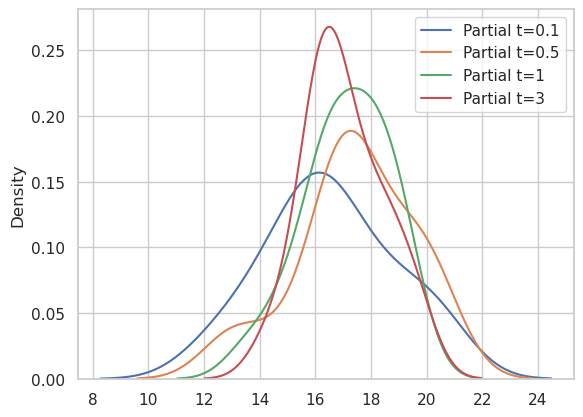

In [63]:
sns.kdeplot(rmsd_01)
sns.kdeplot(rmsd_05)
sns.kdeplot(rmsd_1)
sns.kdeplot(rmsd_3)
plt.legend(['Partial t=0.1', 'Partial t=0.5','Partial t=1', 'Partial t=3'])

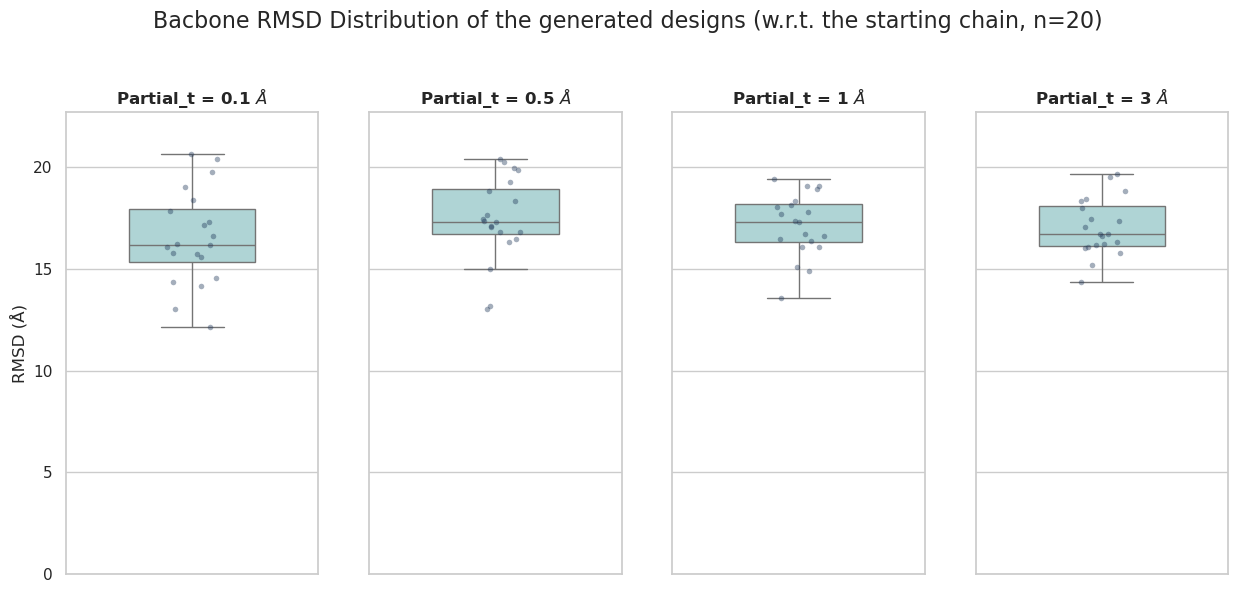

In [64]:
# Set aesthetics
sns.set_theme(style="whitegrid")

# Data pairs - assuming variables rmsd_10, rmsd_15, rmsd_20, rmsd_25 are defined
rmsds = [rmsd_01, rmsd_05, rmsd_1, rmsd_3]
titles = [r"Partial_t = 0.1 $\AA$", r"Partial_t = 0.5 $\AA$", r"Partial_t = 1 $\AA$", r"Partial_t = 3 $\AA$"]
# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(15, 6), sharey=True)

for ax, data, title in zip(axes, rmsds, titles):
    # Main boxplot
    sns.boxplot(y=data, ax=ax, color='#a8dadc', width=0.5, showfliers=False)
    # Individual points
    sns.stripplot(y=data, ax=ax, color='#1d3557', alpha=0.4, jitter=True, size=4)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel("RMSD (Å)") if ax == axes[0] else ax.set_ylabel("")
    ax.set_ylim(0, max([np.max(d) for d in rmsds]) * 1.1)

plt.suptitle("Bacbone RMSD Distribution of the generated designs (w.r.t. the starting chain, n=20)", fontsize=16, y=1.05)
plt.savefig('partial_diffusion_bb_rmsds.png',bbox_inches='tight')

# RFD3 partial diffusion on GPC3 minibinder hits from BindCraft

In [4]:
import numpy as np
from rfd3.engine import RFD3InferenceConfig, RFD3InferenceEngine

In [6]:
from biotite.structure import get_residue_starts
from atomworks.io.utils.io_utils import load_any
from biotite.sequence import ProteinSequence
from atomworks.io.utils.visualize import view
from atomworks.io.utils.io_utils import to_cif_file

In [11]:
input = load_any("/paperspace/Desktop/cancer/gpc3/run_23/re_reordered_modified_gpc3_out_1_l108_s599292_mpnn3_model2_relaxed.pdb")

In [13]:
view(input)

12:03:52 WARNING atomworks.io: AtomArrayStack is not supported; using the first model.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
config = RFD3InferenceConfig(
    specification={
        "dialect": 2,
        "input": "/paperspace/Desktop/cancer/gpc3/run_23/re_reordered_modified_gpc3_out_1_l108_s599292_mpnn3_model2_relaxed.pdb",
        "contig": "A1-108,/0,B1-291",
        "select_fixed_atoms": "B1-291,/0",
        "select_unfixed_sequence": "A1-108,/0",
        "is_non_loopy": True,
        "partial_t": 1.0,
    },
    diffusion_batch_size=1,
)

model = RFD3InferenceEngine(**config)
outputs = model.run(
    inputs=None,
    out_dir=None,
    n_batches=1,
)

first_key = next(iter(outputs.keys()))
atom_array = outputs[first_key][0].atom_array

res_starts = get_residue_starts(outputs[first_key][0].atom_array)
seq_1letter = ''.join(
        ProteinSequence.convert_letter_3to1(res_name)
        for res_name in outputs[first_key][0].atom_array.res_name[res_starts]
    )
print(f"Sequence {seq_1letter}")

# Export structures to CIF format for visualization in PyMOL/ChimeraX
to_cif_file(atom_array, "generated.cif")

view(atom_array)

Using bfloat16 Automatic Mixed Precision (AMP)
12:18:06 WARNING atomworks.io: We can't fix formal charges without building from templates, as we need to know the true number of hydrogens bonded to a given atom, not the inferred number. This may lead to occasional inaccuracies after adding inter-residue bonds. To avoid this and fix formal charges, set `add_missing_atoms = True`.
12:18:06 WARNING atomworks.io: The `extra_fields` argument will be ignored if there is no CIF file input.
12:18:06 WARNING atomworks.ml: Cached data not found for ALA at /net/tukwila/ncorley/datahub/MACE-OFF23_medium/A/ALA/ALA.pt
12:18:06 WARNING atomworks.ml: Cached data not found for ARG at /net/tukwila/ncorley/datahub/MACE-OFF23_medium/A/ARG/ARG.pt
12:18:06 WARNING atomworks.ml: Cached data not found for ASN at /net/tukwila/ncorley/datahub/MACE-OFF23_medium/A/ASN/ASN.pt
12:18:06 WARNING atomworks.ml: Cached data not found for ASP at /net/tukwila/ncorley/datahub/MACE-OFF23_medium/A/ASP/ASP.pt
12:18:06 WARNING 

Sequence AVINLKTAAKELVESLLKQALPPLGLPAALDAALVIDVINTLNYPVKADYIAAAERAAANGASSATLLNIILGATASDVLSASPFDSFDIHLATTNVIQALETLLSSIGSDLQVCLPKGPTCCSRKMEEKYQLTARLNMEQLLQSASKELKFLIIQNAAVFQEAFEIVVRHAKNYTNAMFKNNYPSLTPQAFEFVGEFFTDVSLYILGSDINVDDMVNELFDSLFPVIYTQLMNPGLPDSALDINECLRGARRDLKVFGNFPKLIMTQVSKSLQVTRIFLQALNLGIEVINTTDHLKFSKDCGRMLTRMWYCSYCQGLMMVKPCGGYCNVVMQGCMAGVVEIDKYWREYILSLEELVNGMYRIYDMENVLLGLFSTIHDSIQYVQKNAGKLTTTIGKLC


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
outputs[first_key][0].metadata

OrderedDict([('diffused_index_map', {}),
             ('metrics',
              {'max_ca_deviation': 0.25624537467956543,
               'n_chainbreaks': 0,
               'n_clashing.interresidue_clashes_w_sidechain': 5,
               'n_clashing.interresidue_clashes_w_backbone': 1,
               'non_loop_fraction': np.float64(0.7277227722772277),
               'loop_fraction': np.float64(0.2722772277227723),
               'helix_fraction': np.float64(0.698019801980198),
               'sheet_fraction': np.float64(0.0297029702970297),
               'num_ss_elements': 10,
               'radius_of_gyration': np.float64(29.63037513475233),
               'alanine_content': np.float64(0.08113590263691683),
               'glycine_content': np.float64(0.05070993914807302),
               'num_residues': 493,
               'diffused_com': [-0.38189536333084106,
                1.7200661897659302,
                -2.2781193256378174],
               'fixed_com': [-4.440835952758789,


## Calculate RMSDs

## Test RMSDs

In [ ]:
from atomworks.io.utils.io_utils import load_any
from atomworks.constants import PROTEIN_BACKBONE_ATOM_NAMES
from biotite.structure import rmsd, superimpose
from atomworks.io.utils.visualize import view
import numpy as np

In [ ]:
ref = load_any("gpc3_out_1_l108_s599292_mpnn3_model2_relaxed.pdb")[0]
mob = load_any("rfd3_outputs/partial_diffusion_specification_7_model_1.cif.gz")[0]

In [ ]:
view(mob, height=800, width=1200)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
bb_mob = mob[np.isin(mob.atom_name, ['N', 'CA', 'C', 'O'])]
binder_bb_mob = bb_mob[np.isin(bb_mob.chain_id, "B")]

bb_ref = ref[np.isin(ref.atom_name, ['N', 'CA', 'C', 'O'])]
binder_bb_ref = bb_ref[np.isin(bb_ref.chain_id, "B")]

In [ ]:
binder_bb_mob_fitted, _ = superimpose(binder_bb_ref, binder_bb_mob)
rmsd_value = rmsd(binder_bb_ref, binder_bb_mob_fitted)
print(rmsd_value)

21.473122


# MPNN and RFD3 from a pdb

In [ ]:
import numpy as np
import pandas as pd

from biotite.structure.io import load_structure
from mpnn.inference_engines.mpnn import MPNNInferenceEngine
from rf3.inference_engines.rf3 import RF3InferenceEngine
from rf3.utils.inference import InferenceInput

from biotite.structure import get_residue_starts
from biotite.sequence import ProteinSequence
from biotite.structure import rmsd, superimpose

from atomworks.constants import PROTEIN_BACKBONE_ATOM_NAMES
from atomworks.io.utils.io_utils import to_cif_file

Environment variable CCD_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the atomworks.io repository
Environment variable PDB_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the atomworks.io repository
05:59:59 INFO rdkit: Enabling RDKit 2025.03.6 jupyter extensions


In [ ]:
path = "./generated.cif"
x = load_structure(path)
atom_array = x

In [ ]:
engine_config = {
    'model_type': "protein_mpnn",
    "is_legacy_weights": True,
    "out_directory": "new",
    "write_structures": True,
    "write_fasta": False,
}

input_configs = [
    {
        "batch_size": 8,
        "remove_waters": True,
        "fixed_chains": ["B"],
        "temperature": 0.001,
    }
]

model = MPNNInferenceEngine(**engine_config)
mpnn_outputs = model.run(input_dicts=input_configs, atom_arrays=[atom_array])

06:00:02 INFO mpnn.inference_engines.mpnn: [rank: 0] Loading legacy MPNN weights.
06:00:05 INFO mpnn.utils.inference: Annotated AtomArray has 7715 atoms 
06:00:05 INFO mpnn.inference_engines.mpnn: [rank: 0] Running MPNN inference for input 0, batch 0...


In [ ]:
print(f"Generated {len(mpnn_outputs)} designed sequences:\n")

for i, item in enumerate(mpnn_outputs):
    res_starts = get_residue_starts(item.atom_array)
    # Convert 3-letter codes to 1-letter using Biotite
    seq_1letter = ''.join(
        ProteinSequence.convert_letter_3to1(res_name)
        for res_name in item.atom_array.res_name[res_starts]
    )
    print(f"Sequence {i+1}: {seq_1letter}")

Generated 8 designed sequences:

Sequence 1: NVLKKIVEKGLITYEEAKKMGMSDEEIKKLIEENKIVSLEINGKKYYRITLAGIKYMKENNIGSDLQVCLPKGPTCCSRKMEEKYQLTARLNMEQLLQSASMELKFLIIQNAAVFQEAFEIVVRHAKNYTNAMFKNNYPSLTPQAFEFVGEFFTDVSLYILGSDINVDDMVNELFDSLFPVIYTQLMNPGLPDSALDINECLRGARRDLKVFGNFPKLIMTQVSKSLQVTRIFLQALNLGIEVINTTDHLKFSKDCGRMLTRMWYCSYCQGLMMVKPCGGYCNVVMQGCMAGVVEIDKYWREYILSLEELVNGMYRIYDMENVLLGLFSTIHDSIQYVQKNAGKLTTTIGKLCAHSQQRQYRSAYYPEDLFIDKKVLKVAHVEHEETLSSRRRELIQKLKSFISFYSALPGYICSHSPVAENDTLCWNGQELVERYSQKAARNGMKNQFNLHELKMKGPEPVVSQIIDKLKHINQLLRTMS
Sequence 2: NVLKKIVEKGKITYEEAKKMGMSDEEIEELIKNNYIISIEEDGKKYLVITKLGIEYRKKNNLGSDLQVCLPKGPTCCSRKMEEKYQLTARLNMEQLLQSASMELKFLIIQNAAVFQEAFEIVVRHAKNYTNAMFKNNYPSLTPQAFEFVGEFFTDVSLYILGSDINVDDMVNELFDSLFPVIYTQLMNPGLPDSALDINECLRGARRDLKVFGNFPKLIMTQVSKSLQVTRIFLQALNLGIEVINTTDHLKFSKDCGRMLTRMWYCSYCQGLMMVKPCGGYCNVVMQGCMAGVVEIDKYWREYILSLEELVNGMYRIYDMENVLLGLFSTIHDSIQYVQKNAGKLTTTIGKLCAHSQQRQYRSAYYPEDLFIDKKVLKVAHVEHEETLSSRRRELIQKLKSFISFYSALPGYICSHSPVAENDTLCWNGQELVERYSQKAARNGMKNQFNLHELKMKGPEP

In [ ]:
inference_engine = RF3InferenceEngine(ckpt_path='rf3', verbose=False)
input_structure = InferenceInput.from_atom_array(mpnn_outputs[2].atom_array,example_id="binder", template_selection="B")
rf3_outputs = inference_engine.run(inputs=input_structure)

06:17:49 WARNING atomworks.io: The `extra_fields` argument will be ignored if there is no CIF file input.
06:17:49 WARNING atomworks.io: Adding missing atoms will erase extra fields. If you just want to load a structure with the given extra fields, you should probably use the much faster 'load_any' function from atomworks.io.utils.io_utils instead of 'parse'. Parse is meant for cleaning up structures from the RCSB PDB.


06:17:49 INFO rf3.inference_engines.rf3: [rank: 0] Loading checkpoint from /home/ubuntu/.foundry/checkpoints/rf3_foundry_01_24_latest_remapped.ckpt...
06:17:50 WARNING atomworks.ml: Using element type for atom names of atomized tokens.
Using bfloat16 Automatic Mixed Precision (AMP)
06:17:53 WARNING rf3.inference_engines.rf3: [rank: 0] out_dir is None - results will be returned in memory! If you want to save to disk, please provide an out_dir.
06:17:53 INFO rf3.inference_engines.rf3: [rank: 0] Found 1 structures to predict!
06:17:53 INFO rf3.inference_engines.rf3: [rank: 0] Predicting structure 1/1: binder
06:17:53 WARNING atomworks.ml: Cached data not found for ALA at /net/tukwila/lschaaf/datahub/MACE-OMOL-Jul2025/mace_embeddings/A/ALA/ALA.pt
06:17:53 WARNING atomworks.ml: Cached data not found for ARG at /net/tukwila/lschaaf/datahub/MACE-OMOL-Jul2025/mace_embeddings/A/ARG/ARG.pt
06:17:53 WARNING atomworks.ml: Cached data not found for ASN at /net/tukwila/lschaaf/datahub/MACE-OMOL-Jul2

In [ ]:
rf3_output = rf3_outputs['binder'][0]
res_starts = get_residue_starts(rf3_output.atom_array)
    # Convert 3-letter codes to 1-letter using Biotite
seq_1letter = ''.join(
    ProteinSequence.convert_letter_3to1(res_name)
    for res_name in rf3_output.atom_array.res_name[res_starts]
)
print(f"Sequence {i+1}: {seq_1letter}")

Sequence 8: GFLKKLVENGYITYEEAKEMGVSDETLEYLIENNYITSIEENGKTLYVITLEGIKYMKENNLGSDLQVCLPKGPTCCSRKMEEKYQLTARLNMEQLLQSASMELKFLIIQNAAVFQEAFEIVVRHAKNYTNAMFKNNYPSLTPQAFEFVGEFFTDVSLYILGSDINVDDMVNELFDSLFPVIYTQLMNPGLPDSALDINECLRGARRDLKVFGNFPKLIMTQVSKSLQVTRIFLQALNLGIEVINTTDHLKFSKDCGRMLTRMWYCSYCQGLMMVKPCGGYCNVVMQGCMAGVVEIDKYWREYILSLEELVNGMYRIYDMENVLLGLFSTIHDSIQYVQKNAGKLTTTIGKLCAHSQQRQYRSAYYPEDLFIDKKVLKVAHVEHEETLSSRRRELIQKLKSFISFYSALPGYICSHSPVAENDTLCWNGQELVERYSQKAARNGMKNQFNLHELKMKGPEPVVSQIIDKLKHINQLLRTMS


In [ ]:
rf3_output = rf3_outputs['binder'][0]
res_starts = get_residue_starts(rf3_output.atom_array)
    # Convert 3-letter codes to 1-letter using Biotite
seq_1letter = ''.join(
    ProteinSequence.convert_letter_3to1(res_name)
    for res_name in rf3_output.atom_array.res_name[res_starts]
)
print(f"Sequence {i+1}: {seq_1letter}")

Sequence 8: MVINKIITEGSLELSELLKLGASAATIDELIANASVVALNLDSQTLFAATAAGIAYAINTQAGSDLQVCLPKGPTCCSRKMEEKYQLTARLNMEQLLQSASMELKFLIIQNAAVFQEAFEIVVRHAKNYTNAMFKNNYPSLTPQAFEFVGEFFTDVSLYILGSDINVDDMVNELFDSLFPVIYTQLMNPGLPDSALDINECLRGARRDLKVFGNFPKLIMTQVSKSLQVTRIFLQALNLGIEVINTTDHLKFSKDCGRMLTRMWYCSYCQGLMMVKPCGGYCNVVMQGCMAGVVEIDKYWREYILSLEELVNGMYRIYDMENVLLGLFSTIHDSIQYVQKNAGKLTTTIGKLCAHSQQRQYRSAYYPEDLFIDKKVLKVAHVEHEETLSSRRRELIQKLKSFISFYSALPGYICSHSPVAENDTLCWNGQELVERYSQKAARNGMKNQFNLHELKMKGPEPVVSQIIDKLKHINQLLRTMS


In [ ]:
res_starts = get_residue_starts(atom_array)
    # Convert 3-letter codes to 1-letter using Biotite
seq_1letter = ''.join(
    ProteinSequence.convert_letter_3to1(res_name)
    for res_name in atom_array.res_name[res_starts]
)
print(f"Sequence {i+1}: {seq_1letter}")

Sequence 8: MVINKIITEGSLELSELLKLGASAATIDELIANASVVALNLDSQTLFAATAAGIAYAINTQAGSDLQVCLPKGPTCCSRKMEEKYQLTARLNMEQLLQSASMELKFLIIQNAAVFQEAFEIVVRHAKNYTNAMFKNNYPSLTPQAFEFVGEFFTDVSLYILGSDINVDDMVNELFDSLFPVIYTQLMNPGLPDSALDINECLRGARRDLKVFGNFPKLIMTQVSKSLQVTRIFLQALNLGIEVINTTDHLKFSKDCGRMLTRMWYCSYCQGLMMVKPCGGYCNVVMQGCMAGVVEIDKYWREYILSLEELVNGMYRIYDMENVLLGLFSTIHDSIQYVQKNAGKLTTTIGKLCAHSQQRQYRSAYYPEDLFIDKKVLKVAHVEHEETLSSRRRELIQKLKSFISFYSALPGYICSHSPVAENDTLCWNGQELVERYSQKAARNGMKNQFNLHELKMKGPEPVVSQIIDKLKHINQLLRTMS


# Get contigs

In [19]:
from pathlib import Path

import biotite.structure as struc
from biotite.structure.io import load_structure

pdb = Path("./rfd_20/reordered_modified_gpc3_out_1_l108_s599292_mpnn3_model2_relaxed.pdb")
atom_array = load_structure(pdb)

chain_ids = struc.get_chains(atom_array)

start_stop = []
for chain in chain_ids:
    chain_mask = (atom_array.chain_id == chain)
    chain_res_ids = atom_array.res_id[chain_mask]
    start_stop.append(str(chain_res_ids[0]))
    start_stop.append(str(chain_res_ids[-1]))

In [27]:
contig = [f"{start_stop[1]}-{start_stop[1]}/0 "]

for i, item in enumerate(start_stop):
    if i//2 == 0:
        continue
    if i%2 == 0:
        contig.append(chain_ids[i//2])
        contig.append(item)
        contig.append("-")
    else:
        contig.append(item)
        contig.append("/0 ")

contig = "".join(contig)

contig

'108-108/0 B1-291/0 '